### 1. conda 환경 생성 및 활성화
터미널에서 실행:  
conda create -n autogluon_env python=3.10 -y

conda activate autogluon_env

이후 환경 안에서 AutoGluon 설치:

pip install -U pip wheel setuptools

pip install autogluon.tabular -q 


In [1]:
# 파일: autogluon_run.py (예시)

import pandas as pd
from autogluon.tabular import TabularPredictor

# 1) 데이터 로드
train_path = "../data/train.tsv"
test_path = "../data/test.tsv"

# TSV 이므로 sep="\t" 사용
train_df = pd.read_csv(train_path, sep="\t")
test_df = pd.read_csv(test_path, sep="\t")


In [2]:

train_df = train_df.drop(columns=['train_id'])
test_df = test_df.drop(columns=['test_id'])


In [3]:

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# 2) 타깃 / ID 컬럼 이름 설정
TARGET_COL = "price"   # 실제 타깃 컬럼명으로 바꿔 주세요
ID_COL = None           # 제출용 ID 컬럼명으로 바꿔 주세요 (없으면 None)


Train shape: (1482535, 7)
Test shape: (693359, 6)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    mean_squared_log_error,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error,
)
from autogluon.tabular import TabularPredictor
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# 1. AutoGluon 학습
# ============================================================================
print("=" * 70)
print("AutoGluon 모델 학습 시작")
print("=" * 70)


predictor = TabularPredictor(
    label=TARGET_COL,
    problem_type="regression",  # 명시적으로 회귀 문제 지정
    eval_metric="rmse",  # 커스텀 RMSLE 지표 사용
    path="autogluon_models_imp",
).fit(
    train_data=train_df,
    presets="medium_quality_faster_train",
    time_limit=600,
    # 추가 설정
    verbosity=2,
    # num_bag_folds=5,  # 앙상블 강화 (시간 여유 있으면)
    # num_stack_levels=1,  # 스태킹 레벨
)

print("\n✓ 모델 학습 완료")

# ============================================================================
# 2. 리더보드 확인 (모델별 성능)
# ============================================================================
print("\n" + "=" * 70)
print("모델별 성능 리더보드")
print("=" * 70)

# 기본 리더보드 생성
leaderboard_df = predictor.leaderboard(train_df, silent=True)
print("\n기본 리더보드:")
# 존재하는 컬럼만 선택
available_cols = ["model", "score_val", "pred_time_val", "fit_time"]
print(leaderboard_df[available_cols].head(10))

# 각 모델별로 모든 지표 수동 계산
print("\n" + "=" * 70)
print("각 모델별 상세 평가지표 계산 중...")
print("=" * 70)

y_true_val = train_df[TARGET_COL].copy()
X_val = train_df.drop(TARGET_COL, axis=1)

# 결과 저장용 리스트
model_metrics = []

for idx, row in leaderboard_df.head(10).iterrows():  # Top 10 모델
    model_name = row["model"]
    print(f"\n처리 중: {model_name}")

    try:
        y_pred = predictor.predict(X_val, model=model_name)

        # 음수 값 처리
        y_true_clean = np.maximum(y_true_val.values, 0)
        y_pred_clean = np.maximum(y_pred, 0)

        # 모든 지표 계산
        metrics = {
            "model": model_name,
            "score_val": row["score_val"],
            "rmse": -row["score_val"],  # score_val은 음수 RMSE
            "rmsle": np.sqrt(mean_squared_log_error(y_true_clean, y_pred_clean)),
            "mae": mean_absolute_error(y_true_val, y_pred),
            "r2": r2_score(y_true_val, y_pred),
            "mape": mean_absolute_percentage_error(y_true_val.replace(0, 0.001), y_pred)
            * 100,
            "pred_time_val": row["pred_time_val"],
            "fit_time": row["fit_time"],
        }

        model_metrics.append(metrics)
        print(
            f"  ✓ RMSLE: {metrics['rmsle']:.6f}, RMSE: {metrics['rmse']:.6f}, MAE: {metrics['mae']:.6f}, R²: {metrics['r2']:.6f}"
        )

    except Exception as e:
        print(f"  ✗ 평가 실패: {str(e)[:100]}")

# 결과를 DataFrame으로 변환
if model_metrics:
    metrics_df = pd.DataFrame(model_metrics)

    print("\n" + "=" * 70)
    print("완성된 리더보드 (전체 평가지표)")
    print("=" * 70)
    print(
        metrics_df[["model", "rmse", "rmsle", "mae", "r2", "mape"]].to_string(
            index=False
        )
    )

    print("\n" + "=" * 70)
    print("시간 지표")
    print("=" * 70)
    print(metrics_df[["model", "pred_time_val", "fit_time"]].to_string(index=False))

    # 최고 성능 모델
    best_model_metrics = metrics_df.iloc[0]
    print("\n" + "=" * 70)
    print(f"✓ 최고 성능 모델: {best_model_metrics['model']}")
    print("=" * 70)
    print(f"  RMSE:  {best_model_metrics['rmse']:>10.6f}")
    print(f"  RMSLE: {best_model_metrics['rmsle']:>10.6f}  ⭐ (대회 평가지표)")
    print(f"  MAE:   {best_model_metrics['mae']:>10.6f}")
    print(f"  R²:    {best_model_metrics['r2']:>10.6f}")
    print(f"  MAPE:  {best_model_metrics['mape']:>9.2f}%")

    # 리더보드 업데이트 (나중에 사용하기 위해)
    leaderboard_df = metrics_df
    best_model = best_model_metrics["model"]
else:
    print("\n⚠ 평가지표 계산에 실패했습니다. 기본 리더보드를 사용합니다.")
    best_model = leaderboard_df.iloc[0]["model"]

# ============================================================================
# 3. Train 데이터 상세 평가
# ============================================================================
print("\n" + "=" * 70)
print("Train 데이터 상세 성능 평가")
print("=" * 70)

# Train 데이터로 예측
y_true_train = train_df[TARGET_COL].copy()
X_train = train_df.drop(TARGET_COL, axis=1)

try:
    y_pred_train = predictor.predict(X_train)

    # 음수 값 처리 (RMSLE 계산을 위해)
    y_true_clean = np.maximum(y_true_train.values, 0)
    y_pred_clean = np.maximum(y_pred_train.values, 0)

    # 모든 평가 지표 계산
    train_metrics = {
        "RMSLE": np.sqrt(mean_squared_log_error(y_true_clean, y_pred_clean)),
        "RMSE": np.sqrt(mean_squared_error(y_true_train, y_pred_train)),
        "MAE": mean_absolute_error(y_true_train, y_pred_train),
        "R²": r2_score(y_true_train, y_pred_train),
        "MAPE": mean_absolute_percentage_error(
            y_true_train.replace(0, 0.001), y_pred_train
        )
        * 100,  # 0 방지
    }

    # 추가 통계
    residuals = y_true_train - y_pred_train
    train_metrics["Mean Residual"] = residuals.mean()
    train_metrics["Std Residual"] = residuals.std()
    train_metrics["Max Overestimate"] = residuals.max()
    train_metrics["Max Underestimate"] = residuals.min()

    print("\n[Train 데이터 성능 지표]")
    for metric, value in train_metrics.items():
        if metric in ["RMSLE", "RMSE", "MAE", "R²"]:
            print(f"  {metric:20s}: {value:>12.6f}")
        elif "MAPE" in metric:
            print(f"  {metric:20s}: {value:>11.2f}%")
        else:
            print(f"  {metric:20s}: {value:>12.2f}")

    # 예측값 분포 통계
    print("\n[예측값 분포 통계]")
    print(
        f"  실제값 평균: {y_true_train.mean():.2f}, 표준편차: {y_true_train.std():.2f}"
    )
    print(
        f"  예측값 평균: {y_pred_train.mean():.2f}, 표준편차: {y_pred_train.std():.2f}"
    )
    print(f"  예측값 범위: [{y_pred_train.min():.2f}, {y_pred_train.max():.2f}]")

    # 예측 정확도 분석
    within_10_percent = (np.abs(residuals) / (y_true_train + 1e-8) <= 0.1).sum()
    within_20_percent = (np.abs(residuals) / (y_true_train + 1e-8) <= 0.2).sum()
    print(f"\n[예측 정확도]")
    print(
        f"  10% 이내 예측: {within_10_percent:,} ({within_10_percent/len(y_true_train)*100:.1f}%)"
    )
    print(
        f"  20% 이내 예측: {within_20_percent:,} ({within_20_percent/len(y_true_train)*100:.1f}%)"
    )

except Exception as e:
    print(f"⚠ Train 데이터 평가 중 오류 발생: {e}")
    print("  Validation 성능은 리더보드를 참고하세요.")

# ============================================================================
# 4. 특성 중요도 (Feature Importance)
# ============================================================================
print("\n" + "=" * 70)
print("특성 중요도 (Feature Importance)")
print("=" * 70)

try:
    feature_importance = predictor.feature_importance(train_df)
    print("\nTop 20 중요 특성:")
    print(feature_importance.head(20))

    # 특성 중요도 시각화
    plt.figure(figsize=(10, 8))
    top_features = feature_importance.head(20)
    plt.barh(range(len(top_features)), top_features["importance"])
    plt.yticks(range(len(top_features)), top_features["importance"].index)
    plt.xlabel("Importance Score")
    plt.title("Top 20 Feature Importance")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig("feature_importance_fast.png", dpi=300, bbox_inches="tight")
    print("\n✓ 특성 중요도 그래프 저장: feature_importance.png")
    plt.close()

except Exception as e:
    print(f"⚠ 특성 중요도 계산 실패: {e}")

# ============================================================================
# 5. 테스트 데이터 예측
# ============================================================================
print("\n" + "=" * 70)
print("테스트 데이터 예측")
print("=" * 70)

test_preds = predictor.predict(test_df)
print(f"\n✓ 예측 완료: {len(test_preds):,} 건")

# 테스트 예측값 통계
print(f"\n[테스트 예측값 통계]")
print(f"  평균: {test_preds.mean():.2f}")
print(f"  중앙값: {test_preds.median():.2f}")
print(f"  표준편차: {test_preds.std():.2f}")
print(f"  최소값: {test_preds.min():.2f}")
print(f"  최대값: {test_preds.max():.2f}")
print(f"  25% 분위수: {test_preds.quantile(0.25):.2f}")
print(f"  75% 분위수: {test_preds.quantile(0.75):.2f}")

# 음수 예측값 확인 및 처리
negative_count = (test_preds < 0).sum()
if negative_count > 0:
    print(f"\n⚠ 음수 예측값 발견: {negative_count} 건")
    print(f"  음수 예측값을 0으로 변경합니다.")
    test_preds = np.maximum(test_preds, 0)

# ============================================================================
# 6. 제출 파일 생성
# ============================================================================
print("\n" + "=" * 70)
print("제출 파일 생성")
print("=" * 70)

if ID_COL in test_df.columns:
    submission = pd.DataFrame({ID_COL: test_df[ID_COL], TARGET_COL: test_preds})
else:
    submission = pd.DataFrame({"id": range(len(test_preds)), TARGET_COL: test_preds})

submission_path = "submission_autogluon_fast.csv"
submission.to_csv(submission_path, index=False)
print(f"\n✓ 제출 파일 저장: {submission_path}")
print(f"  형태: {submission.shape}")
print(f"\n제출 파일 미리보기:")
print(submission.head(10))

# ============================================================================
# 7. 예측값 분포 시각화
# ============================================================================
print("\n" + "=" * 70)
print("예측값 분포 시각화")
print("=" * 70)

try:
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # 1) Train 실제값 vs 예측값
    if "y_pred_train" in locals():
        axes[0, 0].scatter(y_true_train, y_pred_train, alpha=0.3, s=1)
        axes[0, 0].plot(
            [y_true_train.min(), y_true_train.max()],
            [y_true_train.min(), y_true_train.max()],
            "r--",
            lw=2,
            label="Perfect Prediction",
        )
        axes[0, 0].set_xlabel("Actual Price")
        axes[0, 0].set_ylabel("Predicted Price")
        axes[0, 0].set_title("Train: Actual vs Predicted")
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

    # 2) Residual 분포
    if "residuals" in locals():
        axes[0, 1].hist(residuals, bins=100, edgecolor="black", alpha=0.7)
        axes[0, 1].axvline(0, color="r", linestyle="--", linewidth=2)
        axes[0, 1].set_xlabel("Residual (Actual - Predicted)")
        axes[0, 1].set_ylabel("Frequency")
        axes[0, 1].set_title("Residual Distribution")
        axes[0, 1].grid(True, alpha=0.3)

    # 3) Train vs Test 예측값 분포 비교
    if "y_pred_train" in locals():
        axes[1, 0].hist(
            y_pred_train,
            bins=50,
            alpha=0.5,
            label="Train Predictions",
            edgecolor="black",
        )
    axes[1, 0].hist(
        test_preds, bins=50, alpha=0.5, label="Test Predictions", edgecolor="black"
    )
    axes[1, 0].set_xlabel("Predicted Price")
    axes[1, 0].set_ylabel("Frequency")
    axes[1, 0].set_title("Train vs Test Predictions Distribution")
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # 4) Test 예측값 Box Plot
    axes[1, 1].boxplot(test_preds, vert=True)
    axes[1, 1].set_ylabel("Predicted Price")
    axes[1, 1].set_title("Test Predictions Box Plot")
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("prediction_analysis_fast.png", dpi=300, bbox_inches="tight")
    print("\n✓ 예측 분석 그래프 저장: prediction_analysis.png")
    plt.close()

except Exception as e:
    print(f"⚠ 시각화 생성 실패: {e}")

# ============================================================================
# 8. 최종 요약
# ============================================================================
print("\n" + "=" * 70)
print("최종 요약")
print("=" * 70)

print(f"\n[모델 정보]")
print(f"  최고 성능 모델: {best_model}")
print(f"  저장 경로: {predictor.path}")
print(f"  평가 지표: {predictor.eval_metric}")

if "train_metrics" in locals():
    print(f"\n[Train 성능]")
    print(f"  RMSLE: {train_metrics['RMSLE']:.6f}")
    print(f"  RMSE:  {train_metrics['RMSE']:.6f}")
    print(f"  MAE:   {train_metrics['MAE']:.6f}")
    print(f"  R²:    {train_metrics['R²']:.6f}")

print(f"\n[제출 정보]")
print(f"  제출 파일: {submission_path}")
print(f"  예측 건수: {len(test_preds):,}")
print(f"  예측 평균: {test_preds.mean():.2f}")

print("\n" + "=" * 70)
print("✓ 모든 작업 완료!")
print("=" * 70)

Preset alias specified: 'medium_quality_faster_train' maps to 'medium_quality'.
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.10.19
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.19045
CPU Count:          12
Memory Avail:       18.68 GB / 31.91 GB (58.5%)
Disk Space Avail:   303.33 GB / 465.09 GB (65.2%)
Presets specified: ['medium_quality_faster_train']
Using hyperparameters preset: hyperparameters='default'


AutoGluon 모델 학습 시작


Beginning AutoGluon training ... Time limit = 600s
AutoGluon will save models to "c:\big20\git\big20-ML-project2-team3\MercariPriceSuggestion\src\autogluon_models_imp"
Train Data Rows:    1482535
Train Data Columns: 6
Label Column:       price
Problem Type:       regression
Preprocessing data ...
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    19678.71 MB
	Train Data (Original)  Memory Usage: 656.23 MB (3.3% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
			Note: Converting 1 features to boolean dtype as they only contain 2 unique values.
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGenerator...
		Fitting CategoryFeatureGenerator...
			Fitting CategoryMemoryMinimizeFeatureGenerator


✓ 모델 학습 완료

모델별 성능 리더보드

기본 리더보드:
                 model  score_val  pred_time_val   fit_time
0           LightGBMXT -28.221874       0.116597  31.216716
1  WeightedEnsemble_L2 -28.221874       0.116597  31.226668

각 모델별 상세 평가지표 계산 중...

처리 중: LightGBMXT
  ✓ RMSLE: 0.564566, RMSE: 28.221874, MAE: 12.319811, R²: 0.480975

처리 중: WeightedEnsemble_L2
  ✓ RMSLE: 0.564566, RMSE: 28.221874, MAE: 12.319811, R²: 0.480975

완성된 리더보드 (전체 평가지표)
              model      rmse    rmsle       mae       r2        mape
         LightGBMXT 28.221874 0.564566 12.319811 0.480975 1590.016799
WeightedEnsemble_L2 28.221874 0.564566 12.319811 0.480975 1590.016799

시간 지표
              model  pred_time_val  fit_time
         LightGBMXT       0.116597 31.216716
WeightedEnsemble_L2       0.116597 31.226668

✓ 최고 성능 모델: LightGBMXT
  RMSE:   28.221874
  RMSLE:   0.564566  ⭐ (대회 평가지표)
  MAE:    12.319811
  R²:      0.480975
  MAPE:    1590.02%

Train 데이터 상세 성능 평가


Computing feature importance via permutation shuffling for 6 features using 5000 rows with 5 shuffle sets...



[Train 데이터 성능 지표]
  RMSLE               :     0.564566
  RMSE                :    27.798705
  MAE                 :    12.319811
  R²                  :     0.480975
  MAPE                :     1590.02%
  Mean Residual       :         0.00
  Std Residual        :        27.80
  Max Overestimate    :      1981.96
  Max Underestimate   :      -497.60

[예측값 분포 통계]
  실제값 평균: 26.74, 표준편차: 38.59
  예측값 평균: 26.74, 표준편차: 23.88
  예측값 범위: [-40.39, 1099.98]

[예측 정확도]
  10% 이내 예측: 210,533 (14.2%)
  20% 이내 예측: 412,889 (27.9%)

특성 중요도 (Feature Importance)


	22.69s	= Expected runtime (4.54s per shuffle set)
	20.38s	= Actual runtime (Completed 5 of 5 shuffle sets)



Top 20 중요 특성:
                   importance    stddev   p_value  n   p99_high   p99_low
category_name        7.118281  1.727221  0.000385  5  10.674653  3.561909
brand_name           4.749632  1.785227  0.002003  5   8.425439  1.073825
item_description     2.715675  0.982273  0.001739  5   4.738188  0.693162
name                 1.829492  0.911471  0.005460  5   3.706223 -0.047240
item_condition_id    0.870453  0.137951  0.000073  5   1.154497  0.586409
shipping             0.243712  0.187774  0.022010  5   0.630341 -0.142917

✓ 특성 중요도 그래프 저장: feature_importance.png

테스트 데이터 예측

✓ 예측 완료: 693,359 건

[테스트 예측값 통계]
  평균: 26.71
  중앙값: 21.03
  표준편차: 23.69
  최소값: -30.06
  최대값: 1007.06
  25% 분위수: 15.44
  75% 분위수: 30.36

⚠ 음수 예측값 발견: 74 건
  음수 예측값을 0으로 변경합니다.

제출 파일 생성

✓ 제출 파일 저장: submission_autogluon_fast.csv
  형태: (693359, 2)

제출 파일 미리보기:
   id      price
0   0  14.252057
1   1   8.905739
2   2  63.466145
3   3  20.211161
4   4   9.130729
5   5   5.205914
6   6  15.040818
7   7  55.370399
8

In [ ]:
# 1) 가장 중요한 성능 지표 (score_val)를 기준으로 정렬합니다.
# AutoGluon의 리더보드는 이미 점수가 높은 순서(회귀의 경우 -RMSE)로 정렬되어 있습니다.
plot_data = leaderboard_df.copy() # 상위 10개 모델만 시각화 (선택 사항)

# 2) 막대 그래프 생성
plt.figure(figsize=(10, 6))
bar_plot = sns.barplot(
    x='score_val', # 성능 지표 (y축 값)
    y='model',     # 모델 이름 (x축 값)
    data=plot_data,
    palette='viridis'
)

# 3) 그래프 제목 및 라벨 설정
plt.title('AutoGluon Top Model Performance Comparison (score_val)', fontsize=16)
plt.xlabel(f'Performance Score ({predictor.eval_metric})', fontsize=12) # 평가 지표 이름을 사용
plt.ylabel('Model Name', fontsize=12)

# 4) 각 막대에 점수 텍스트 추가
for index, row in plot_data.iterrows():
    # 소수점 4자리까지 표시
    bar_plot.text(row['score_val'], index, f'{row["score_val"]:.4f}',
                  color='black', ha="left", va='center')

plt.gca().invert_yaxis() # 성능이 좋은 모델(점수가 높은)이 위에 오도록 y축 순서 뒤집기
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8, 8))
sns.scatterplot(
    x='pred_time_val', # X축: 추론 시간 (낮을수록 좋음)
    y='score_val',     # Y축: 성능 점수 (높을수록 좋음)
    data=leaderboard_df,
    hue='model',       # 모델 종류별로 색상 구분
    size='score_val',  # 성능이 좋을수록 점 크기 키우기
    sizes=(50, 500)
)

plt.title('Accuracy vs. Inference Speed Tradeoff', fontsize=16)
plt.xlabel('Prediction Time (seconds on validation data)', fontsize=12)
plt.ylabel(f'Performance Score ({predictor.eval_metric})', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(rect=[0, 0, 0.85, 1]) # 범례 공간 확보
plt.show()

Preset alias specified: 'medium_quality_faster_train' maps to 'medium_quality'.
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.10.19
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.19045
CPU Count:          12
Memory Avail:       23.96 GB / 31.91 GB (75.1%)
Disk Space Avail:   311.55 GB / 465.09 GB (67.0%)
Presets specified: ['medium_quality_faster_train']
Using hyperparameters preset: hyperparameters='default'


AutoGluon 모델 학습 시작


Beginning AutoGluon training ... Time limit = 7200s
AutoGluon will save models to "c:\big20\git\big20-ML-project2-team3\MercariPriceSuggestion\src\autogluon_models_fast"
Train Data Rows:    1482535
Train Data Columns: 6
Label Column:       price
Problem Type:       regression
Preprocessing data ...
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    25080.07 MB
	Train Data (Original)  Memory Usage: 656.23 MB (2.6% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
			Note: Converting 1 features to boolean dtype as they only contain 2 unique values.
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGenerator...
		Fitting CategoryFeatureGenerator...
			Fitting CategoryMemoryMinimizeFeatureGenerat

[1000]	valid_set's rmse: 27.5964
[2000]	valid_set's rmse: 27.1788
[3000]	valid_set's rmse: 27.0407
[4000]	valid_set's rmse: 26.9605
[5000]	valid_set's rmse: 26.9355
[6000]	valid_set's rmse: 26.8845
[7000]	valid_set's rmse: 26.8798
[8000]	valid_set's rmse: 26.8388
[9000]	valid_set's rmse: 26.8297
[10000]	valid_set's rmse: 26.8034


	-26.7993	 = Validation score   (-root_mean_squared_error)
	324.16s	 = Training   runtime
	3.53s	 = Validation runtime
Fitting model: LightGBM ... Training model for up to 6311.66s of the 6311.66s of remaining time.
	Fitting with cpus=6, gpus=0, mem=8.5/20.5 GB


...


✓ 모델 학습 완료

모델별 성능 리더보드

기본 리더보드:
                 model  score_val  pred_time_val     fit_time
0      RandomForestMSE -29.619102       0.161527  4761.898901
1             LightGBM -26.757219       2.061462   258.174267
2  WeightedEnsemble_L2 -26.446389       6.086591  6633.335101
3           LightGBMXT -26.799312       3.530535   324.164883
4             CatBoost -28.740300       0.332064  1289.081057

각 모델별 상세 평가지표 계산 중...

처리 중: RandomForestMSE
  ✓ RMSLE: 0.541076, RMSE: 29.619102, MAE: 10.634863, R²: 0.777422

처리 중: LightGBM
  ✓ RMSLE: 0.494894, RMSE: 26.757219, MAE: 9.788765, R²: 0.748110

처리 중: WeightedEnsemble_L2
  ✓ RMSLE: 0.484168, RMSE: 26.446389, MAE: 9.858068, R²: 0.731504

처리 중: LightGBMXT
  ✓ RMSLE: 0.512162, RMSE: 26.799312, MAE: 10.333663, R²: 0.695410

처리 중: CatBoost
  ✓ RMSLE: 0.546077, RMSE: 28.740300, MAE: 12.173318, R²: 0.437300

완성된 리더보드 (전체 평가지표)
              model      rmse    rmsle       mae       r2        mape
    RandomForestMSE 29.619102 0.541076 10.63486

Computing feature importance via permutation shuffling for 6 features using 5000 rows with 5 shuffle sets...



[Train 데이터 성능 지표]
  RMSLE               :     0.484168
  RMSE                :    19.993975
  MAE                 :     9.858068
  R²                  :     0.731504
  MAPE                :     1437.73%
  Mean Residual       :         0.01
  Std Residual        :        19.99
  Max Overestimate    :      1563.06
  Max Underestimate   :      -352.31

[예측값 분포 통계]
  실제값 평균: 26.74, 표준편차: 38.59
  예측값 평균: 26.73, 표준편차: 28.31
  예측값 범위: [-36.39, 1641.50]

[예측 정확도]
  10% 이내 예측: 259,827 (17.5%)
  20% 이내 예측: 501,121 (33.8%)

특성 중요도 (Feature Importance)


	119.29s	= Expected runtime (23.86s per shuffle set)
	96.82s	= Actual runtime (Completed 5 of 5 shuffle sets)



Top 20 중요 특성:
                   importance    stddev   p_value  n   p99_high   p99_low
category_name       11.500969  3.638368  0.001057  5  18.992419  4.009518
brand_name           8.400536  2.806596  0.001296  5  14.179357  2.621716
item_description     8.382587  3.795503  0.003913  5  16.197581  0.567593
name                 5.218761  2.459097  0.004501  5  10.282075  0.155446
item_condition_id    1.808098  0.471439  0.000508  5   2.778796  0.837399
shipping             0.608154  0.256731  0.003050  5   1.136767  0.079542


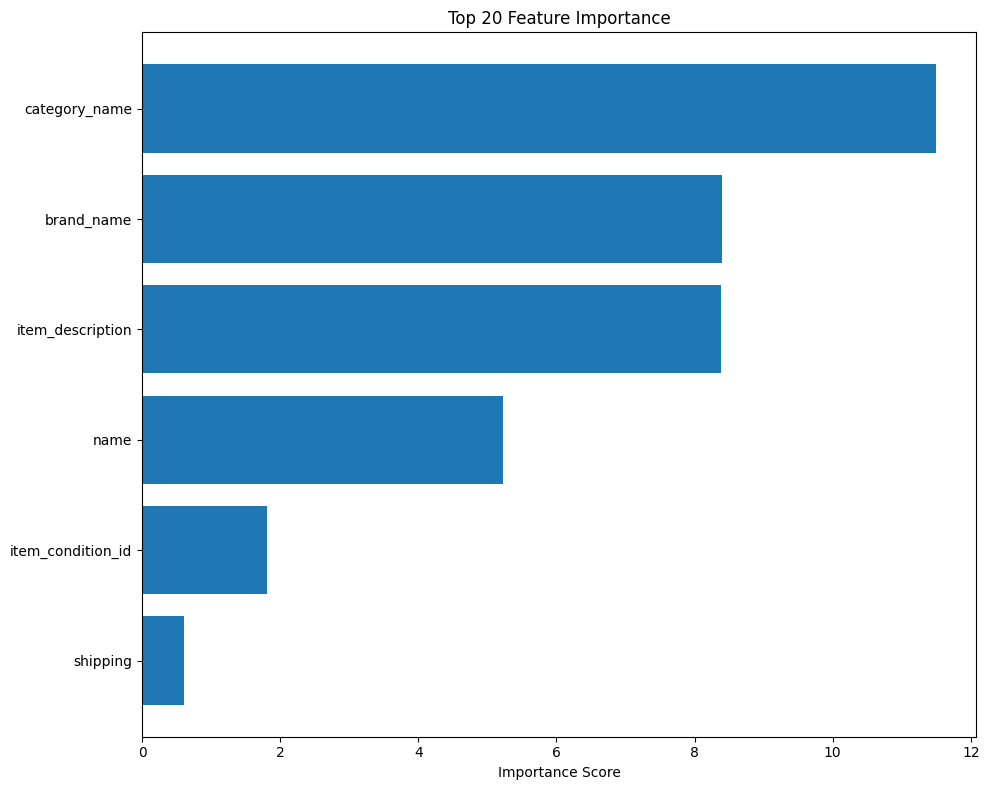


테스트 데이터 예측

✓ 예측 완료: 693,359 건

[테스트 예측값 통계]
  평균: 26.70
  중앙값: 20.37
  표준편차: 25.95
  최소값: -34.60
  최대값: 1452.32
  25% 분위수: 14.51
  75% 분위수: 30.20

⚠ 음수 예측값 발견: 328 건
  음수 예측값을 0으로 변경합니다.

제출 파일 생성

✓ 제출 파일 저장: submission_autogluon.csv
  형태: (693359, 2)

제출 파일 미리보기:
   id      price
0   0  12.224430
1   1  10.956002
2   2  69.016457
3   3  17.105562
4   4   8.938518
5   5   9.803017
6   6  37.290871
7   7  47.330391
8   8  55.832714
9   9  14.795348

예측값 분포 시각화


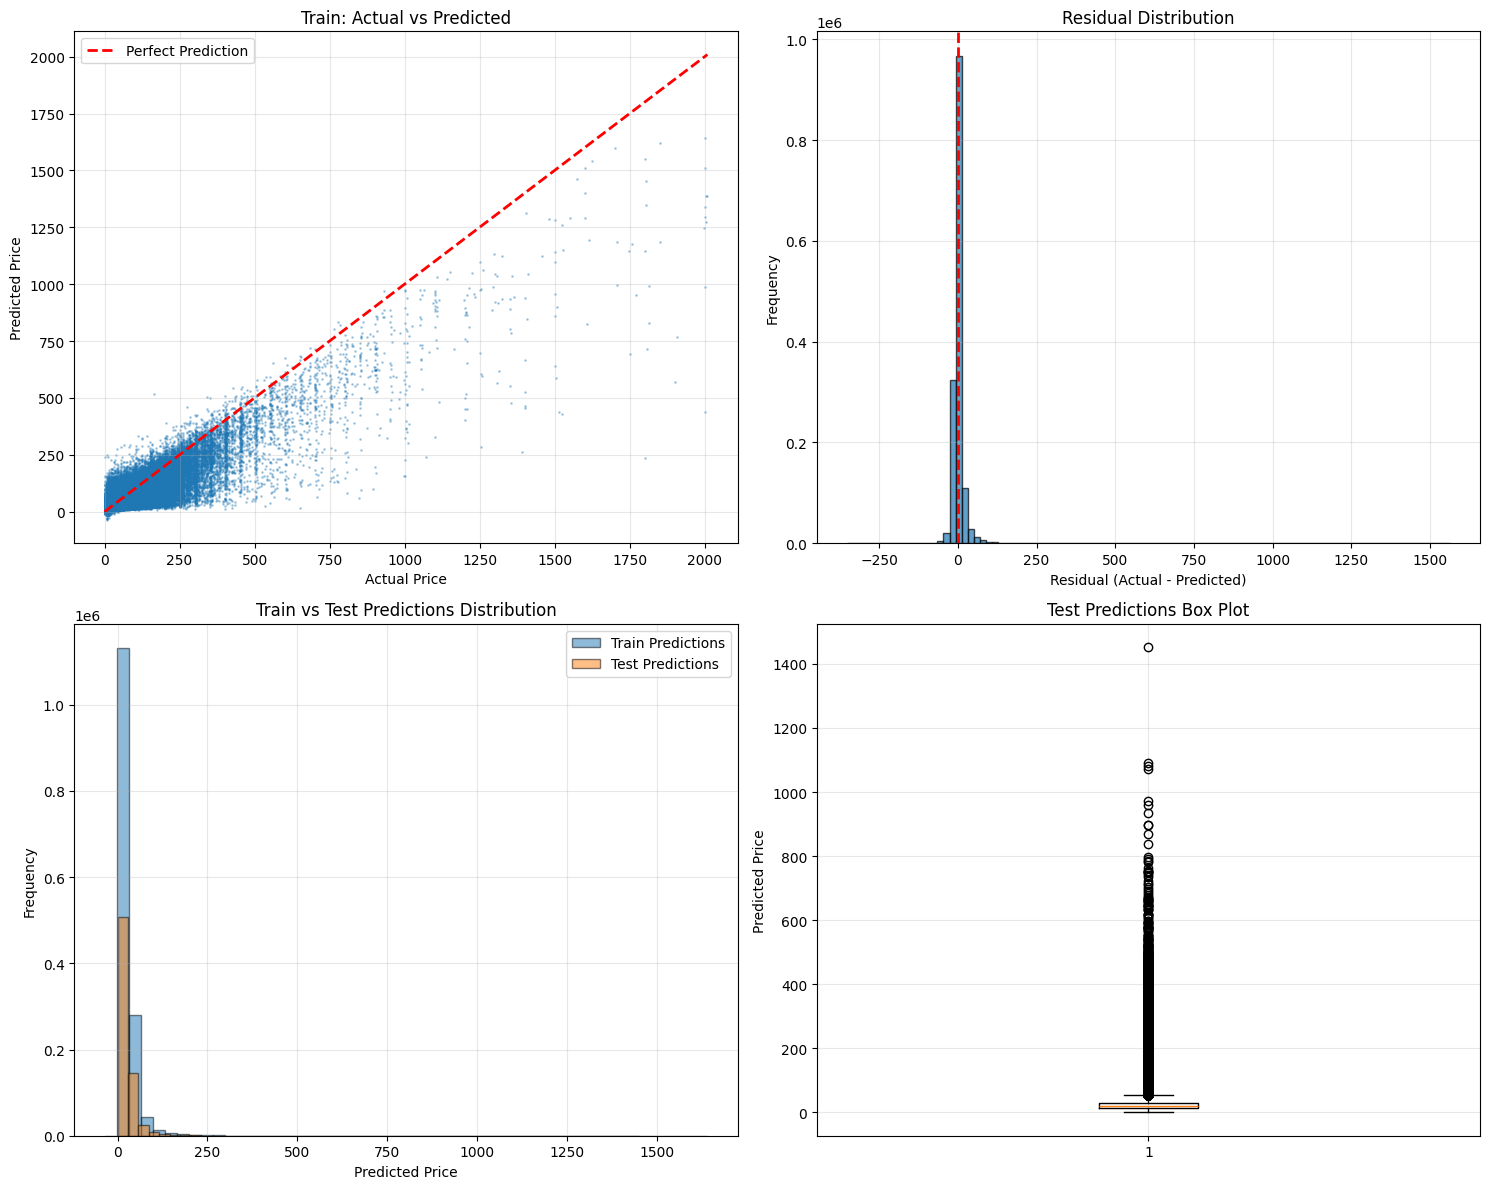


최종 요약

[모델 정보]
  최고 성능 모델: RandomForestMSE
  저장 경로: c:\big20\git\big20-ML-project2-team3\MercariPriceSuggestion\src\autogluon_models_fast
  평가 지표: root_mean_squared_error

[Train 성능]
  RMSLE: 0.484168
  RMSE:  19.993975
  MAE:   9.858068
  R²:    0.731504

[제출 정보]
  제출 파일: submission_autogluon.csv
  예측 건수: 693,359
  예측 평균: 26.71

✓ 모든 작업 완료!


In [4]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    mean_squared_log_error,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error,
)
from autogluon.tabular import TabularPredictor
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# 1. AutoGluon 학습
# ============================================================================
print("=" * 70)
print("AutoGluon 모델 학습 시작")
print("=" * 70)


predictor = TabularPredictor(
    label=TARGET_COL,
    problem_type="regression",  # 명시적으로 회귀 문제 지정
    eval_metric="rmse",  # 커스텀 RMSLE 지표 사용
    path="autogluon_models_fast",
).fit(
    train_data=train_df,
    presets="medium_quality_faster_train",
    time_limit=7200,
    # 추가 설정
    verbosity=2,
    # num_bag_folds=5,  # 앙상블 강화 (시간 여유 있으면)
    # num_stack_levels=1,  # 스태킹 레벨
)

print("\n✓ 모델 학습 완료")

# ============================================================================
# 2. 리더보드 확인 (모델별 성능)
# ============================================================================
print("\n" + "=" * 70)
print("모델별 성능 리더보드")
print("=" * 70)

# 기본 리더보드 생성
leaderboard_df = predictor.leaderboard(train_df, silent=True)
print("\n기본 리더보드:")
# 존재하는 컬럼만 선택
available_cols = ["model", "score_val", "pred_time_val", "fit_time"]
print(leaderboard_df[available_cols].head(10))

# 각 모델별로 모든 지표 수동 계산
print("\n" + "=" * 70)
print("각 모델별 상세 평가지표 계산 중...")
print("=" * 70)

y_true_val = train_df[TARGET_COL].copy()
X_val = train_df.drop(TARGET_COL, axis=1)

# 결과 저장용 리스트
model_metrics = []

for idx, row in leaderboard_df.head(10).iterrows():  # Top 10 모델
    model_name = row["model"]
    print(f"\n처리 중: {model_name}")

    try:
        y_pred = predictor.predict(X_val, model=model_name)

        # 음수 값 처리
        y_true_clean = np.maximum(y_true_val.values, 0)
        y_pred_clean = np.maximum(y_pred, 0)

        # 모든 지표 계산
        metrics = {
            "model": model_name,
            "score_val": row["score_val"],
            "rmse": -row["score_val"],  # score_val은 음수 RMSE
            "rmsle": np.sqrt(mean_squared_log_error(y_true_clean, y_pred_clean)),
            "mae": mean_absolute_error(y_true_val, y_pred),
            "r2": r2_score(y_true_val, y_pred),
            "mape": mean_absolute_percentage_error(y_true_val.replace(0, 0.001), y_pred)
            * 100,
            "pred_time_val": row["pred_time_val"],
            "fit_time": row["fit_time"],
        }

        model_metrics.append(metrics)
        print(
            f"  ✓ RMSLE: {metrics['rmsle']:.6f}, RMSE: {metrics['rmse']:.6f}, MAE: {metrics['mae']:.6f}, R²: {metrics['r2']:.6f}"
        )

    except Exception as e:
        print(f"  ✗ 평가 실패: {str(e)[:100]}")

# 결과를 DataFrame으로 변환
if model_metrics:
    metrics_df = pd.DataFrame(model_metrics)

    print("\n" + "=" * 70)
    print("완성된 리더보드 (전체 평가지표)")
    print("=" * 70)
    print(
        metrics_df[["model", "rmse", "rmsle", "mae", "r2", "mape"]].to_string(
            index=False
        )
    )

    print("\n" + "=" * 70)
    print("시간 지표")
    print("=" * 70)
    print(metrics_df[["model", "pred_time_val", "fit_time"]].to_string(index=False))

    # 최고 성능 모델
    best_model_metrics = metrics_df.iloc[0]
    print("\n" + "=" * 70)
    print(f"✓ 최고 성능 모델: {best_model_metrics['model']}")
    print("=" * 70)
    print(f"  RMSE:  {best_model_metrics['rmse']:>10.6f}")
    print(f"  RMSLE: {best_model_metrics['rmsle']:>10.6f}  ⭐ (대회 평가지표)")
    print(f"  MAE:   {best_model_metrics['mae']:>10.6f}")
    print(f"  R²:    {best_model_metrics['r2']:>10.6f}")
    print(f"  MAPE:  {best_model_metrics['mape']:>9.2f}%")

    # 리더보드 업데이트 (나중에 사용하기 위해)
    leaderboard_df = metrics_df
    best_model = best_model_metrics["model"]
else:
    print("\n⚠ 평가지표 계산에 실패했습니다. 기본 리더보드를 사용합니다.")
    best_model = leaderboard_df.iloc[0]["model"]

# ============================================================================
# 3. Train 데이터 상세 평가
# ============================================================================
print("\n" + "=" * 70)
print("Train 데이터 상세 성능 평가")
print("=" * 70)

# Train 데이터로 예측
y_true_train = train_df[TARGET_COL].copy()
X_train = train_df.drop(TARGET_COL, axis=1)

try:
    y_pred_train = predictor.predict(X_train)

    # 음수 값 처리 (RMSLE 계산을 위해)
    y_true_clean = np.maximum(y_true_train.values, 0)
    y_pred_clean = np.maximum(y_pred_train.values, 0)

    # 모든 평가 지표 계산
    train_metrics = {
        "RMSLE": np.sqrt(mean_squared_log_error(y_true_clean, y_pred_clean)),
        "RMSE": np.sqrt(mean_squared_error(y_true_train, y_pred_train)),
        "MAE": mean_absolute_error(y_true_train, y_pred_train),
        "R²": r2_score(y_true_train, y_pred_train),
        "MAPE": mean_absolute_percentage_error(
            y_true_train.replace(0, 0.001), y_pred_train
        )
        * 100,  # 0 방지
    }

    # 추가 통계
    residuals = y_true_train - y_pred_train
    train_metrics["Mean Residual"] = residuals.mean()
    train_metrics["Std Residual"] = residuals.std()
    train_metrics["Max Overestimate"] = residuals.max()
    train_metrics["Max Underestimate"] = residuals.min()

    print("\n[Train 데이터 성능 지표]")
    for metric, value in train_metrics.items():
        if metric in ["RMSLE", "RMSE", "MAE", "R²"]:
            print(f"  {metric:20s}: {value:>12.6f}")
        elif "MAPE" in metric:
            print(f"  {metric:20s}: {value:>11.2f}%")
        else:
            print(f"  {metric:20s}: {value:>12.2f}")

    # 예측값 분포 통계
    print("\n[예측값 분포 통계]")
    print(
        f"  실제값 평균: {y_true_train.mean():.2f}, 표준편차: {y_true_train.std():.2f}"
    )
    print(
        f"  예측값 평균: {y_pred_train.mean():.2f}, 표준편차: {y_pred_train.std():.2f}"
    )
    print(f"  예측값 범위: [{y_pred_train.min():.2f}, {y_pred_train.max():.2f}]")

    # 예측 정확도 분석
    within_10_percent = (np.abs(residuals) / (y_true_train + 1e-8) <= 0.1).sum()
    within_20_percent = (np.abs(residuals) / (y_true_train + 1e-8) <= 0.2).sum()
    print(f"\n[예측 정확도]")
    print(
        f"  10% 이내 예측: {within_10_percent:,} ({within_10_percent/len(y_true_train)*100:.1f}%)"
    )
    print(
        f"  20% 이내 예측: {within_20_percent:,} ({within_20_percent/len(y_true_train)*100:.1f}%)"
    )

except Exception as e:
    print(f"⚠ Train 데이터 평가 중 오류 발생: {e}")
    print("  Validation 성능은 리더보드를 참고하세요.")

# ============================================================================
# 4. 특성 중요도 (Feature Importance)
# ============================================================================
print("\n" + "=" * 70)
print("특성 중요도 (Feature Importance)")
print("=" * 70)

try:
    feature_importance = predictor.feature_importance(train_df)
    print("\nTop 20 중요 특성:")
    print(feature_importance.head(20))

    # 특성 중요도 시각화
    plt.figure(figsize=(10, 8))
    top_features = feature_importance.head(20)
    plt.barh(range(len(top_features)), top_features["importance"])
    plt.yticks(range(len(top_features)), top_features["importance"].index)
    plt.xlabel("Importance Score")
    plt.title("Top 20 Feature Importance")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    # plt.savefig("../images/feature_importance.png", dpi=300, bbox_inches="tight")
    # print("\n✓ 특성 중요도 그래프 저장: feature_importance.png")
    # plt.close()
    plt.show()

except Exception as e:
    print(f"⚠ 특성 중요도 계산 실패: {e}")

# ============================================================================
# 5. 테스트 데이터 예측
# ============================================================================
print("\n" + "=" * 70)
print("테스트 데이터 예측")
print("=" * 70)

test_preds = predictor.predict(test_df)
print(f"\n✓ 예측 완료: {len(test_preds):,} 건")

# 테스트 예측값 통계
print(f"\n[테스트 예측값 통계]")
print(f"  평균: {test_preds.mean():.2f}")
print(f"  중앙값: {test_preds.median():.2f}")
print(f"  표준편차: {test_preds.std():.2f}")
print(f"  최소값: {test_preds.min():.2f}")
print(f"  최대값: {test_preds.max():.2f}")
print(f"  25% 분위수: {test_preds.quantile(0.25):.2f}")
print(f"  75% 분위수: {test_preds.quantile(0.75):.2f}")

# 음수 예측값 확인 및 처리
negative_count = (test_preds < 0).sum()
if negative_count > 0:
    print(f"\n⚠ 음수 예측값 발견: {negative_count} 건")
    print(f"  음수 예측값을 0으로 변경합니다.")
    test_preds = np.maximum(test_preds, 0)

# ============================================================================
# 6. 제출 파일 생성
# ============================================================================
print("\n" + "=" * 70)
print("제출 파일 생성")
print("=" * 70)

if ID_COL in test_df.columns:
    submission = pd.DataFrame({ID_COL: test_df[ID_COL], TARGET_COL: test_preds})
else:
    submission = pd.DataFrame({"id": range(len(test_preds)), TARGET_COL: test_preds})

submission_path = "submission_autogluon.csv"
submission.to_csv(submission_path, index=False)
print(f"\n✓ 제출 파일 저장: {submission_path}")
print(f"  형태: {submission.shape}")
print(f"\n제출 파일 미리보기:")
print(submission.head(10))

# ============================================================================
# 7. 예측값 분포 시각화
# ============================================================================
print("\n" + "=" * 70)
print("예측값 분포 시각화")
print("=" * 70)

try:
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # 1) Train 실제값 vs 예측값
    if "y_pred_train" in locals():
        axes[0, 0].scatter(y_true_train, y_pred_train, alpha=0.3, s=1)
        axes[0, 0].plot(
            [y_true_train.min(), y_true_train.max()],
            [y_true_train.min(), y_true_train.max()],
            "r--",
            lw=2,
            label="Perfect Prediction",
        )
        axes[0, 0].set_xlabel("Actual Price")
        axes[0, 0].set_ylabel("Predicted Price")
        axes[0, 0].set_title("Train: Actual vs Predicted")
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

    # 2) Residual 분포
    if "residuals" in locals():
        axes[0, 1].hist(residuals, bins=100, edgecolor="black", alpha=0.7)
        axes[0, 1].axvline(0, color="r", linestyle="--", linewidth=2)
        axes[0, 1].set_xlabel("Residual (Actual - Predicted)")
        axes[0, 1].set_ylabel("Frequency")
        axes[0, 1].set_title("Residual Distribution")
        axes[0, 1].grid(True, alpha=0.3)

    # 3) Train vs Test 예측값 분포 비교
    if "y_pred_train" in locals():
        axes[1, 0].hist(
            y_pred_train,
            bins=50,
            alpha=0.5,
            label="Train Predictions",
            edgecolor="black",
        )
    axes[1, 0].hist(
        test_preds, bins=50, alpha=0.5, label="Test Predictions", edgecolor="black"
    )
    axes[1, 0].set_xlabel("Predicted Price")
    axes[1, 0].set_ylabel("Frequency")
    axes[1, 0].set_title("Train vs Test Predictions Distribution")
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # 4) Test 예측값 Box Plot
    axes[1, 1].boxplot(test_preds, vert=True)
    axes[1, 1].set_ylabel("Predicted Price")
    axes[1, 1].set_title("Test Predictions Box Plot")
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    # plt.savefig("../images/prediction_analysis.png", dpi=300, bbox_inches="tight")
    # print("\n✓ 예측 분석 그래프 저장: prediction_analysis.png")
    # plt.close()
    plt.show()

except Exception as e:
    print(f"⚠ 시각화 생성 실패: {e}")

# ============================================================================
# 8. 최종 요약
# ============================================================================
print("\n" + "=" * 70)
print("최종 요약")
print("=" * 70)

print(f"\n[모델 정보]")
print(f"  최고 성능 모델: {best_model}")
print(f"  저장 경로: {predictor.path}")
print(f"  평가 지표: {predictor.eval_metric}")

if "train_metrics" in locals():
    print(f"\n[Train 성능]")
    print(f"  RMSLE: {train_metrics['RMSLE']:.6f}")
    print(f"  RMSE:  {train_metrics['RMSE']:.6f}")
    print(f"  MAE:   {train_metrics['MAE']:.6f}")
    print(f"  R²:    {train_metrics['R²']:.6f}")

print(f"\n[제출 정보]")
print(f"  제출 파일: {submission_path}")
print(f"  예측 건수: {len(test_preds):,}")
print(f"  예측 평균: {test_preds.mean():.2f}")

print("\n" + "=" * 70)
print("✓ 모든 작업 완료!")
print("=" * 70)

In [12]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    mean_squared_log_error,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error,
)
from autogluon.tabular import TabularPredictor
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# 1. AutoGluon 학습
# ============================================================================
print("=" * 70)
print("AutoGluon 모델 학습 시작")
print("=" * 70)


predictor = TabularPredictor(
    label=TARGET_COL,
    problem_type="regression",  # 명시적으로 회귀 문제 지정
    eval_metric="rmse",  # 커스텀 RMSLE 지표 사용
    path="autogluon_models",
).fit(
    train_data=train_df,
    presets="best_quality",
    time_limit=7200,
    # 추가 설정
    verbosity=2,
    # num_bag_folds=5,  # 앙상블 강화 (시간 여유 있으면)
    # num_stack_levels=1,  # 스태킹 레벨
)

print("\n✓ 모델 학습 완료")

# ============================================================================
# 2. 리더보드 확인 (모델별 성능)
# ============================================================================
print("\n" + "=" * 70)
print("모델별 성능 리더보드")
print("=" * 70)

# 기본 리더보드 생성
leaderboard_df = predictor.leaderboard(train_df, silent=True)
print("\n기본 리더보드:")
# 존재하는 컬럼만 선택
available_cols = ["model", "score_val", "pred_time_val", "fit_time"]
print(leaderboard_df[available_cols].head(10))

# 각 모델별로 모든 지표 수동 계산
print("\n" + "=" * 70)
print("각 모델별 상세 평가지표 계산 중...")
print("=" * 70)

y_true_val = train_df[TARGET_COL].copy()
X_val = train_df.drop(TARGET_COL, axis=1)

# 결과 저장용 리스트
model_metrics = []

for idx, row in leaderboard_df.head(10).iterrows():  # Top 10 모델
    model_name = row["model"]
    print(f"\n처리 중: {model_name}")

    try:
        y_pred = predictor.predict(X_val, model=model_name)

        # 음수 값 처리
        y_true_clean = np.maximum(y_true_val.values, 0)
        y_pred_clean = np.maximum(y_pred, 0)

        # 모든 지표 계산
        metrics = {
            "model": model_name,
            "score_val": row["score_val"],
            "rmse": -row["score_val"],  # score_val은 음수 RMSE
            "rmsle": np.sqrt(mean_squared_log_error(y_true_clean, y_pred_clean)),
            "mae": mean_absolute_error(y_true_val, y_pred),
            "r2": r2_score(y_true_val, y_pred),
            "mape": mean_absolute_percentage_error(y_true_val.replace(0, 0.001), y_pred)
            * 100,
            "pred_time_val": row["pred_time_val"],
            "fit_time": row["fit_time"],
        }

        model_metrics.append(metrics)
        print(
            f"  ✓ RMSLE: {metrics['rmsle']:.6f}, RMSE: {metrics['rmse']:.6f}, MAE: {metrics['mae']:.6f}, R²: {metrics['r2']:.6f}"
        )

    except Exception as e:
        print(f"  ✗ 평가 실패: {str(e)[:100]}")

# 결과를 DataFrame으로 변환
if model_metrics:
    metrics_df = pd.DataFrame(model_metrics)

    print("\n" + "=" * 70)
    print("완성된 리더보드 (전체 평가지표)")
    print("=" * 70)
    print(
        metrics_df[["model", "rmse", "rmsle", "mae", "r2", "mape"]].to_string(
            index=False
        )
    )

    print("\n" + "=" * 70)
    print("시간 지표")
    print("=" * 70)
    print(metrics_df[["model", "pred_time_val", "fit_time"]].to_string(index=False))

    # 최고 성능 모델
    best_model_metrics = metrics_df.iloc[0]
    print("\n" + "=" * 70)
    print(f"✓ 최고 성능 모델: {best_model_metrics['model']}")
    print("=" * 70)
    print(f"  RMSE:  {best_model_metrics['rmse']:>10.6f}")
    print(f"  RMSLE: {best_model_metrics['rmsle']:>10.6f}  ⭐ (대회 평가지표)")
    print(f"  MAE:   {best_model_metrics['mae']:>10.6f}")
    print(f"  R²:    {best_model_metrics['r2']:>10.6f}")
    print(f"  MAPE:  {best_model_metrics['mape']:>9.2f}%")

    # 리더보드 업데이트 (나중에 사용하기 위해)
    leaderboard_df = metrics_df
    best_model = best_model_metrics["model"]
else:
    print("\n⚠ 평가지표 계산에 실패했습니다. 기본 리더보드를 사용합니다.")
    best_model = leaderboard_df.iloc[0]["model"]

# ============================================================================
# 3. Train 데이터 상세 평가
# ============================================================================
print("\n" + "=" * 70)
print("Train 데이터 상세 성능 평가")
print("=" * 70)

# Train 데이터로 예측
y_true_train = train_df[TARGET_COL].copy()
X_train = train_df.drop(TARGET_COL, axis=1)

try:
    y_pred_train = predictor.predict(X_train)

    # 음수 값 처리 (RMSLE 계산을 위해)
    y_true_clean = np.maximum(y_true_train.values, 0)
    y_pred_clean = np.maximum(y_pred_train.values, 0)

    # 모든 평가 지표 계산
    train_metrics = {
        "RMSLE": np.sqrt(mean_squared_log_error(y_true_clean, y_pred_clean)),
        "RMSE": np.sqrt(mean_squared_error(y_true_train, y_pred_train)),
        "MAE": mean_absolute_error(y_true_train, y_pred_train),
        "R²": r2_score(y_true_train, y_pred_train),
        "MAPE": mean_absolute_percentage_error(
            y_true_train.replace(0, 0.001), y_pred_train
        )
        * 100,  # 0 방지
    }

    # 추가 통계
    residuals = y_true_train - y_pred_train
    train_metrics["Mean Residual"] = residuals.mean()
    train_metrics["Std Residual"] = residuals.std()
    train_metrics["Max Overestimate"] = residuals.max()
    train_metrics["Max Underestimate"] = residuals.min()

    print("\n[Train 데이터 성능 지표]")
    for metric, value in train_metrics.items():
        if metric in ["RMSLE", "RMSE", "MAE", "R²"]:
            print(f"  {metric:20s}: {value:>12.6f}")
        elif "MAPE" in metric:
            print(f"  {metric:20s}: {value:>11.2f}%")
        else:
            print(f"  {metric:20s}: {value:>12.2f}")

    # 예측값 분포 통계
    print("\n[예측값 분포 통계]")
    print(
        f"  실제값 평균: {y_true_train.mean():.2f}, 표준편차: {y_true_train.std():.2f}"
    )
    print(
        f"  예측값 평균: {y_pred_train.mean():.2f}, 표준편차: {y_pred_train.std():.2f}"
    )
    print(f"  예측값 범위: [{y_pred_train.min():.2f}, {y_pred_train.max():.2f}]")

    # 예측 정확도 분석
    within_10_percent = (np.abs(residuals) / (y_true_train + 1e-8) <= 0.1).sum()
    within_20_percent = (np.abs(residuals) / (y_true_train + 1e-8) <= 0.2).sum()
    print(f"\n[예측 정확도]")
    print(
        f"  10% 이내 예측: {within_10_percent:,} ({within_10_percent/len(y_true_train)*100:.1f}%)"
    )
    print(
        f"  20% 이내 예측: {within_20_percent:,} ({within_20_percent/len(y_true_train)*100:.1f}%)"
    )

except Exception as e:
    print(f"⚠ Train 데이터 평가 중 오류 발생: {e}")
    print("  Validation 성능은 리더보드를 참고하세요.")

# ============================================================================
# 4. 특성 중요도 (Feature Importance)
# ============================================================================
print("\n" + "=" * 70)
print("특성 중요도 (Feature Importance)")
print("=" * 70)

try:
    feature_importance = predictor.feature_importance(train_df)
    print("\nTop 20 중요 특성:")
    print(feature_importance.head(20))

    # 특성 중요도 시각화
    plt.figure(figsize=(10, 8))
    top_features = feature_importance.head(20)
    plt.barh(range(len(top_features)), top_features["importance"])
    plt.yticks(range(len(top_features)), top_features["importance"].index)
    plt.xlabel("Importance Score")
    plt.title("Top 20 Feature Importance")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")
    print("\n✓ 특성 중요도 그래프 저장: feature_importance.png")
    plt.close()

except Exception as e:
    print(f"⚠ 특성 중요도 계산 실패: {e}")

# ============================================================================
# 5. 테스트 데이터 예측
# ============================================================================
print("\n" + "=" * 70)
print("테스트 데이터 예측")
print("=" * 70)

test_preds = predictor.predict(test_df)
print(f"\n✓ 예측 완료: {len(test_preds):,} 건")

# 테스트 예측값 통계
print(f"\n[테스트 예측값 통계]")
print(f"  평균: {test_preds.mean():.2f}")
print(f"  중앙값: {test_preds.median():.2f}")
print(f"  표준편차: {test_preds.std():.2f}")
print(f"  최소값: {test_preds.min():.2f}")
print(f"  최대값: {test_preds.max():.2f}")
print(f"  25% 분위수: {test_preds.quantile(0.25):.2f}")
print(f"  75% 분위수: {test_preds.quantile(0.75):.2f}")

# 음수 예측값 확인 및 처리
negative_count = (test_preds < 0).sum()
if negative_count > 0:
    print(f"\n⚠ 음수 예측값 발견: {negative_count} 건")
    print(f"  음수 예측값을 0으로 변경합니다.")
    test_preds = np.maximum(test_preds, 0)

# ============================================================================
# 6. 제출 파일 생성
# ============================================================================
print("\n" + "=" * 70)
print("제출 파일 생성")
print("=" * 70)

if ID_COL in test_df.columns:
    submission = pd.DataFrame({ID_COL: test_df[ID_COL], TARGET_COL: test_preds})
else:
    submission = pd.DataFrame({"id": range(len(test_preds)), TARGET_COL: test_preds})

submission_path = "submission_autogluon.csv"
submission.to_csv(submission_path, index=False)
print(f"\n✓ 제출 파일 저장: {submission_path}")
print(f"  형태: {submission.shape}")
print(f"\n제출 파일 미리보기:")
print(submission.head(10))

# ============================================================================
# 7. 예측값 분포 시각화
# ============================================================================
print("\n" + "=" * 70)
print("예측값 분포 시각화")
print("=" * 70)

try:
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # 1) Train 실제값 vs 예측값
    if "y_pred_train" in locals():
        axes[0, 0].scatter(y_true_train, y_pred_train, alpha=0.3, s=1)
        axes[0, 0].plot(
            [y_true_train.min(), y_true_train.max()],
            [y_true_train.min(), y_true_train.max()],
            "r--",
            lw=2,
            label="Perfect Prediction",
        )
        axes[0, 0].set_xlabel("Actual Price")
        axes[0, 0].set_ylabel("Predicted Price")
        axes[0, 0].set_title("Train: Actual vs Predicted")
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

    # 2) Residual 분포
    if "residuals" in locals():
        axes[0, 1].hist(residuals, bins=100, edgecolor="black", alpha=0.7)
        axes[0, 1].axvline(0, color="r", linestyle="--", linewidth=2)
        axes[0, 1].set_xlabel("Residual (Actual - Predicted)")
        axes[0, 1].set_ylabel("Frequency")
        axes[0, 1].set_title("Residual Distribution")
        axes[0, 1].grid(True, alpha=0.3)

    # 3) Train vs Test 예측값 분포 비교
    if "y_pred_train" in locals():
        axes[1, 0].hist(
            y_pred_train,
            bins=50,
            alpha=0.5,
            label="Train Predictions",
            edgecolor="black",
        )
    axes[1, 0].hist(
        test_preds, bins=50, alpha=0.5, label="Test Predictions", edgecolor="black"
    )
    axes[1, 0].set_xlabel("Predicted Price")
    axes[1, 0].set_ylabel("Frequency")
    axes[1, 0].set_title("Train vs Test Predictions Distribution")
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # 4) Test 예측값 Box Plot
    axes[1, 1].boxplot(test_preds, vert=True)
    axes[1, 1].set_ylabel("Predicted Price")
    axes[1, 1].set_title("Test Predictions Box Plot")
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("prediction_analysis.png", dpi=300, bbox_inches="tight")
    print("\n✓ 예측 분석 그래프 저장: prediction_analysis.png")
    plt.close()

except Exception as e:
    print(f"⚠ 시각화 생성 실패: {e}")

# ============================================================================
# 8. 최종 요약
# ============================================================================
print("\n" + "=" * 70)
print("최종 요약")
print("=" * 70)

print(f"\n[모델 정보]")
print(f"  최고 성능 모델: {best_model}")
print(f"  저장 경로: {predictor.path}")
print(f"  평가 지표: {predictor.eval_metric}")

if "train_metrics" in locals():
    print(f"\n[Train 성능]")
    print(f"  RMSLE: {train_metrics['RMSLE']:.6f}")
    print(f"  RMSE:  {train_metrics['RMSE']:.6f}")
    print(f"  MAE:   {train_metrics['MAE']:.6f}")
    print(f"  R²:    {train_metrics['R²']:.6f}")

print(f"\n[제출 정보]")
print(f"  제출 파일: {submission_path}")
print(f"  예측 건수: {len(test_preds):,}")
print(f"  예측 평균: {test_preds.mean():.2f}")

print("\n" + "=" * 70)
print("✓ 모든 작업 완료!")
print("=" * 70)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.10.19
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.19045
CPU Count:          12
Memory Avail:       21.10 GB / 31.91 GB (66.1%)
Disk Space Avail:   303.77 GB / 465.09 GB (65.3%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon will be fit on subsets of the data. Then holdout validation data is u

AutoGluon 모델 학습 시작


Leaderboard on holdout data (DyStack):
                 model  score_holdout  score_val              eval_metric  pred_time_test  pred_time_val     fit_time  pred_time_test_marginal  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0  WeightedEnsemble_L3     -27.832658 -27.634456  root_mean_squared_error      122.865768     164.382590  1234.681051                 0.016311                0.016667           0.733429            3       True          4
1    LightGBMXT_BAG_L2     -27.834135 -27.738840  root_mean_squared_error      122.849457     164.365923  1233.947622                25.299901               24.600518         386.915739            2       True          3
2    LightGBMXT_BAG_L1     -27.969395 -27.753401  root_mean_squared_error       97.549556     139.765404   847.031883                97.549556              139.765404         847.031883            1       True          1
3  WeightedEnsemble_L2     -27.969395 -27.753401  root_mean_squared_error    


✓ 모델 학습 완료

모델별 성능 리더보드

기본 리더보드:
                 model  score_val  pred_time_val     fit_time
0    LightGBMXT_BAG_L2 -27.203648     741.194054  4554.358986
1  WeightedEnsemble_L3 -27.044384     741.210796  4555.359008
2    LightGBMXT_BAG_L1 -27.219625     498.239689  2845.275362
3  WeightedEnsemble_L2 -27.217104     504.984827  3061.065073
4      LightGBM_BAG_L1 -28.727223       6.729526   215.017323

각 모델별 상세 평가지표 계산 중...

처리 중: LightGBMXT_BAG_L2
  ✓ RMSLE: 0.476902, RMSE: 27.203648, MAE: 9.838680, R²: 0.708135

처리 중: WeightedEnsemble_L3
  ✓ RMSLE: 0.483033, RMSE: 27.044384, MAE: 9.975580, R²: 0.703125

처리 중: LightGBMXT_BAG_L1
  ✓ RMSLE: 0.502991, RMSE: 27.219625, MAE: 10.257232, R²: 0.691531

처리 중: WeightedEnsemble_L2
  ✓ RMSLE: 0.501489, RMSE: 27.217104, MAE: 10.290591, R²: 0.686122

처리 중: LightGBM_BAG_L1
  ✓ RMSLE: 0.571196, RMSE: 28.727223, MAE: 12.353245, R²: 0.488128

완성된 리더보드 (전체 평가지표)
              model      rmse    rmsle       mae       r2        mape
  LightGBMXT_BAG_L2 

Computing feature importance via permutation shuffling for 6 features using 5000 rows with 5 shuffle sets...



[Train 데이터 성능 지표]
  RMSLE               :     0.483033
  RMSE                :    21.024078
  MAE                 :     9.975580
  R²                  :     0.703125
  MAPE                :     1445.92%
  Mean Residual       :         0.02
  Std Residual        :        21.02
  Max Overestimate    :      1743.31
  Max Underestimate   :      -333.30

[예측값 분포 통계]
  실제값 평균: 26.74, 표준편차: 38.59
  예측값 평균: 26.71, 표준편차: 28.38
  예측값 범위: [-26.78, 1595.65]

[예측 정확도]
  10% 이내 예측: 262,032 (17.7%)
  20% 이내 예측: 506,135 (34.1%)

특성 중요도 (Feature Importance)


	645.46s	= Expected runtime (129.09s per shuffle set)
	588.3s	= Actual runtime (Completed 5 of 5 shuffle sets)



Top 20 중요 특성:
                   importance    stddev   p_value  n   p99_high   p99_low
category_name       10.777598  1.889732  0.000109  5  14.668582  6.886614
item_description     8.424768  1.859023  0.000267  5  12.252522  4.597014
brand_name           7.483382  2.308274  0.000961  5  12.236150  2.730614
name                 5.426693  1.092508  0.000187  5   7.676181  3.177204
item_condition_id    1.607641  0.211430  0.000035  5   2.042977  1.172304
shipping             0.769225  0.179488  0.000331  5   1.138793  0.399658

✓ 특성 중요도 그래프 저장: feature_importance.png

테스트 데이터 예측

✓ 예측 완료: 693,359 건

[테스트 예측값 통계]
  평균: 26.72
  중앙값: 20.03
  표준편차: 26.74
  최소값: -29.75
  최대값: 1338.54
  25% 분위수: 14.15
  75% 분위수: 30.03

⚠ 음수 예측값 발견: 77 건
  음수 예측값을 0으로 변경합니다.

제출 파일 생성

✓ 제출 파일 저장: submission_autogluon.csv
  형태: (693359, 2)

제출 파일 미리보기:
   id      price
0   0  10.603200
1   1  11.757560
2   2  65.066788
3   3  15.947194
4   4   9.132813
5   5  10.395385
6   6  28.102699
7   7  45.312202
8   8 